# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

print("ALL GOOD ✅")

ALL GOOD ✅


In [2]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

sns.set()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mariatirado/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mariatirado/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/mariatirado/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


# Loading the 20th-century data

In [4]:
file_path = "key_events_20th_century.txt"

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read().lower()

print("Characters:", len(text))
print(text[:500])

Characters: 115116
key events of the 20th century - wikipedia
jump to content
main menu
main menu
move to sidebar
hide
navigation
main page
contents
current events
random article
about wikipedia
contact us
contribute
help
learn to edit
community portal
recent changes
upload file
special pages
search
search
appearance
donate
create account
log in
personal tools
donate
create account
log in
contents
move to sidebar
hide
(top)
1
historic events in the 20th century
toggle historic events in the 20th century subsection


# Tokenize the words

In [5]:
from nltk.tokenize import word_tokenize
from collections import Counter

tokens = word_tokenize(text)

# Get the 10 most common words

In [6]:
word_freq = Counter(tokens)
top_10_words = word_freq.most_common(10)

df_top10 = pd.DataFrame(top_10_words, columns=["Word", "Frequency"])
df_top10

,Word,Frequency
0,.,1574
1,the,1479
2,",",983
3,of,629
4,and,419
5,'',395
6,in,346
7,to,337
8,[,309
9,],309


# Create a bar chart

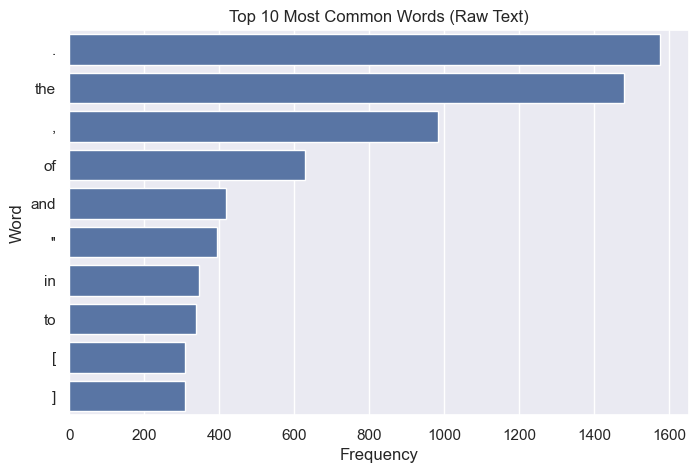

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Frequency", y="Word", data=df_top10)
plt.title("Top 10 Most Common Words (Raw Text)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

# Remove stop words and punctuation

In [8]:
from nltk.corpus import stopwords
import string

stop_words = set(stopwords.words("english"))

clean_tokens = [word for word in tokens
    if word.isalpha() and word not in stop_words]

# Recalculate top 10 words

In [9]:
clean_freq = Counter(clean_tokens)
top_10_clean = clean_freq.most_common(10)

df_top10_clean = pd.DataFrame(
    top_10_clean, columns=["Word", "Frequency"])
df_top10_clean

,Word,Frequency
0,december,231
1,retrieved,210
2,war,208
3,world,118
4,history,72
5,soviet,57
6,new,54
7,first,53
8,hitler,51
9,century,47


# Rerun the bar chart

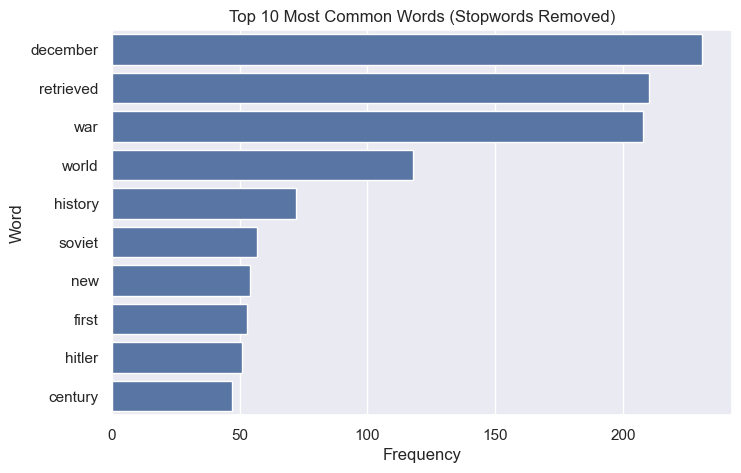

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Frequency", y="Word", data=df_top10_clean)
plt.title("Top 10 Most Common Words (Stopwords Removed)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

# Comments
After removing stop words and punctuation, the most frequent words become more meaningful and content-specific. Instead of common grammatical words such as “the” or “and,” the plot now highlights historically relevant terms related to events, places, and time periods. This makes the data easier to interpret and more useful for further analysis.

# Create a TextBlob object

In [11]:
from textblob import TextBlob

blob = TextBlob(text)

# Create the tags list

In [12]:
tags = blob.tags
tags[:20]

[('key', 'JJ'),
 ('events', 'NNS'),
 ('of', 'IN'),
 ('the', 'DT'),
 ('20th', 'JJ'),
 ('century', 'NN'),
 ('wikipedia', 'NN'),
 ('jump', 'NN'),
 ('to', 'TO'),
 ('content', 'VB'),
 ('main', 'JJ'),
 ('menu', 'NN'),
 ('main', 'JJ'),
 ('menu', 'NN'),
 ('move', 'NN'),
 ('to', 'TO'),
 ('sidebar', 'VB'),
 ('hide', 'JJ'),
 ('navigation', 'NN'),
 ('main', 'JJ')]

# list of the Top 10 POS tags for words

In [13]:
from collections import Counter
import pandas as pd

pos_counts = Counter(tag for word, tag in tags)

top_10_pos = pos_counts.most_common(10)
top_10_pos

[('NN', 5081),
 ('JJ', 2160),
 ('IN', 1973),
 ('DT', 1857),
 ('CD', 1844),
 ('NNS', 1169),
 ('VBD', 994),
 ('RB', 716),
 ('CC', 495),
 ('VBN', 358)]

In [14]:
# Converting to a DataFrame
df_pos = pd.DataFrame(top_10_pos,
    columns=["POS Tag", "Frequency"])

df_pos

,POS Tag,Frequency
0,NN,5081
1,JJ,2160
2,IN,1973
3,DT,1857
4,CD,1844
5,NNS,1169
6,VBD,994
7,RB,716
8,CC,495
9,VBN,358


# Plot the list

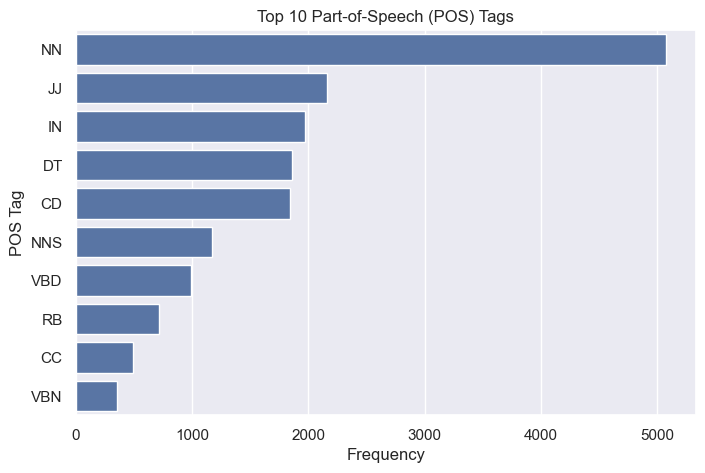

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Frequency",
    y="POS Tag",
    data=df_pos)

plt.title("Top 10 Part-of-Speech (POS) Tags")
plt.xlabel("Frequency")
plt.ylabel("POS Tag")
plt.show()

# Create three bar plots with the top 15 POS labels

In [17]:
# Creating helper function
def plot_top_words_by_pos(tag_prefixes, title):
    words = [
        word for word, tag in tags
        if tag.startswith(tag_prefixes)]
    
    freq = Counter(words).most_common(15)
    df = pd.DataFrame(freq, columns=["Word", "Frequency"])
    
    plt.figure(figsize=(8, 6))
    sns.barplot(x="Frequency", y="Word", data=df)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()

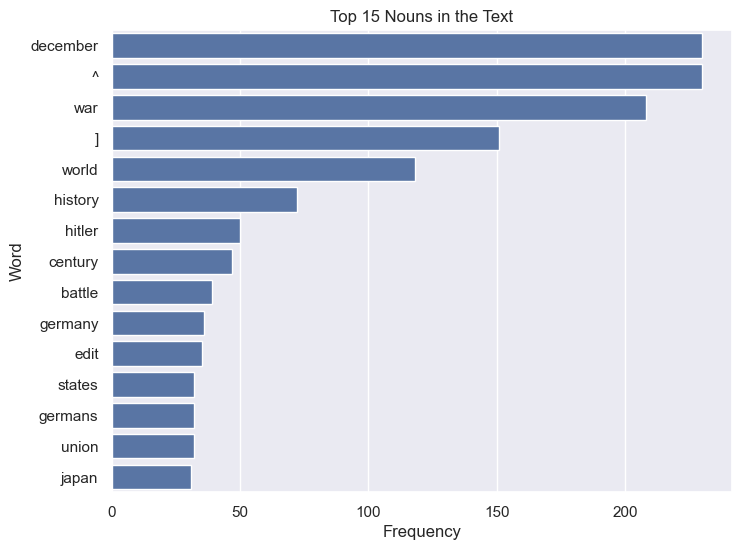

In [18]:
# Plot Top 15 Nouns
plot_top_words_by_pos("NN", "Top 15 Nouns in the Text")

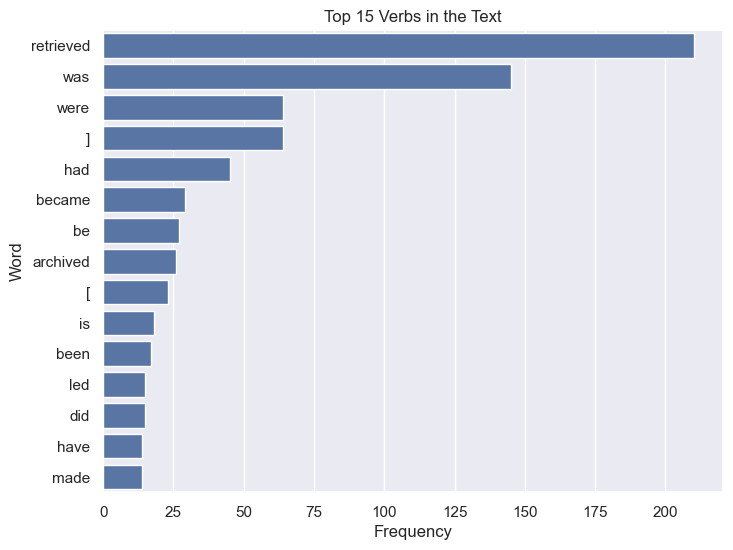

In [19]:
# Plot Top 15 Verbs
plot_top_words_by_pos("VB", "Top 15 Verbs in the Text")

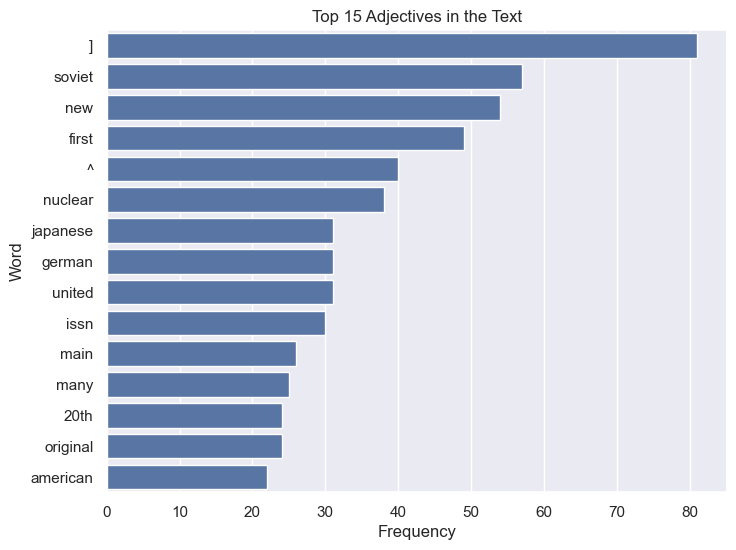

In [20]:
# Plot Top 15 Adjectives
plot_top_words_by_pos("JJ", "Top 15 Adjectives in the Text")

# Comment
The noun frequency plot is dominated by terms related to historical events, countries, and time periods, which reflects the factual and descriptive nature of the text. Verbs appear less frequently and mainly describe actions related to conflict, change, and development, suggesting a narrative focused on major historical processes rather than detailed storytelling. Adjectives occur less often overall and are mostly neutral or descriptive, indicating that the text aims to inform rather than express strong opinions or emotions.

# Create a countries lookup list

In [21]:
countries = ["united states", "germany", "france", "britain", "united kingdom",
    "russia", "soviet union", "china", "japan", "italy", "spain",
    "austria", "poland", "canada", "australia", "india", "korea",
    "vietnam", "mexico"]

# How often each country appears in the text?

In [22]:
country_counts = {}

for country in countries:
    country_counts[country] = text.count(country)

In [23]:
# Creating the dataframe

df_countries = pd.DataFrame(
    country_counts.items(),
    columns=["Country", "Mentions"])

# Sort by frequency
df_countries = df_countries.sort_values(
    by="Mentions", ascending=False)

df_countries

,Country,Mentions
8,japan,69
1,germany,41
6,soviet union,32
0,united states,23
3,britain,20
16,korea,18
5,russia,18
2,france,17
17,vietnam,17
9,italy,14


# Create the bar plot

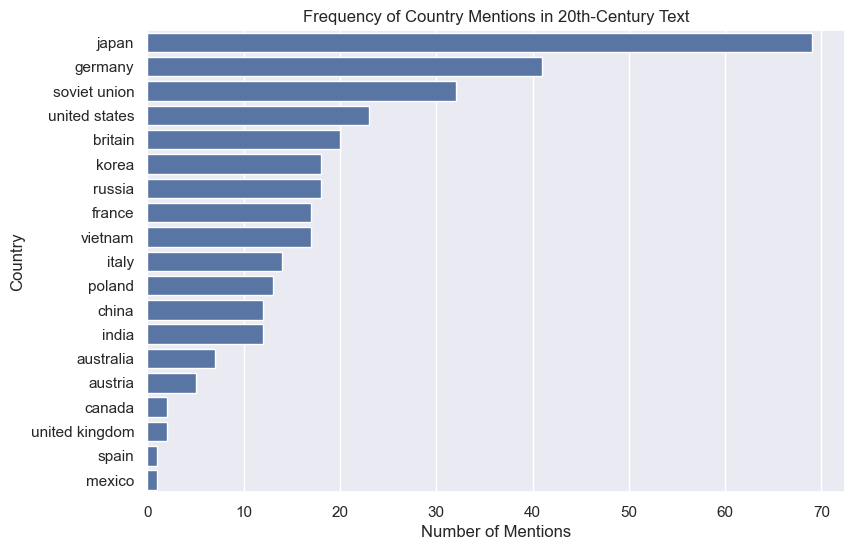

In [24]:
plt.figure(figsize=(9, 6))
sns.barplot(
    x="Mentions",
    y="Country",
    data=df_countries)

plt.title("Frequency of Country Mentions in 20th-Century Text")
plt.xlabel("Number of Mentions")
plt.ylabel("Country")
plt.show()

# Findings

The plot shows that references to countries are highly unevenly distributed throughout the text. A small group of countries—particularly Japan, Germany, the Soviet Union, and the United States—dominate the mentions, reflecting their central role in major 20th-century historical events such as wars, political conflicts, and global power shifts. In contrast, many other countries appear only a few times, indicating that the text focuses primarily on the most influential geopolitical actors rather than providing equal coverage across regions. This highlights the strong emphasis on global powers and conflict-driven narratives in the source material.

# Sentiment Analysis

In [25]:
blob = TextBlob(text)

sentiment = blob.sentiment
sentiment

Sentiment(polarity=0.05756604614430863, subjectivity=0.3709547942689431)

In [26]:
# Sentiment Dataframe
df_sentiment = pd.DataFrame({
    "Metric": ["Polarity", "Subjectivity"],
    "Score": [sentiment.polarity, sentiment.subjectivity]})

df_sentiment

,Metric,Score
0,Polarity,0.057566
1,Subjectivity,0.370955


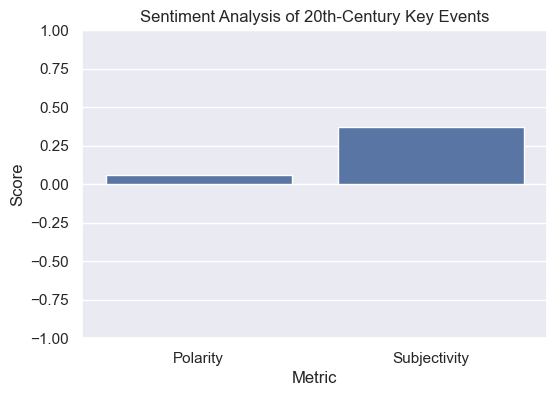

In [27]:
# Plot the sentiment scores

plt.figure(figsize=(6, 4))
sns.barplot(
    x="Metric",
    y="Score",
    data=df_sentiment)

plt.title("Sentiment Analysis of 20th-Century Key Events")
plt.ylabel("Score")
plt.ylim(-1, 1)
plt.show()

# Sentiment Analysis Interpretation 

The sentiment analysis shows that the text has an overall neutral tone, with a polarity score close to zero. This suggests that the language used is neither strongly positive nor strongly negative, which is expected for a historical overview of major 20th-century events. The subjectivity score is relatively low, indicating that the text is mainly factual and informative, with limited emotional or opinion-based language. Overall, the results confirm that the text focuses on reporting historical events rather than expressing sentiment.